In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
DATA = Path("../results/cox")

cox = pd.read_csv(DATA/"cox3_input.tsv", sep="\t", index_col=0)

print("Cox3 input shape: ", cox.shape)

Cox3 input shape:  (285, 5)


In [18]:
cox["event"].value_counts()

event
0    214
1     71
Name: count, dtype: int64

In [15]:
cox[cox["event"] == 1]["FIGO_group"].value_counts()

FIGO_group
I      36
IV     14
II     11
III    10
Name: count, dtype: int64

In [4]:
cox.columns

Index(['time_days', 'event', 'EMT', 'tcga.cgc_case_clinical_stage',
       'FIGO_group'],
      dtype='object')

In [5]:
cox["FIGO_group"].isna().sum()

np.int64(0)

In [6]:
cox["FIGO_group"].value_counts()

FIGO_group
I      159
II      64
III     41
IV      21
Name: count, dtype: int64

In [7]:
from lifelines import CoxPHFitter

#One-hot encode FIGO (drop the reference level)

cox_model = pd.get_dummies(cox[["time_days", "event", "EMT", "FIGO_group"]], columns=["FIGO_group"], drop_first=True)

In [17]:
cox["FIGO_group"].dtype

dtype('O')

In [16]:
cox_model.value_counts()

time_days  event  EMT        FIGO_group_II  FIGO_group_III  FIGO_group_IV
2.0        0       1.411178  True           False           False            1
3.0        0      -1.557834  False          False           False            1
4.0        0       1.673795  False          False           False            1
5.0        0      -0.753222  True           False           False            1
9.0        0      -1.831770  False          False           True             1
                                                                            ..
4879.0     0      -1.645003  False          False           False            1
5271.0     0      -1.246065  False          False           False            1
5385.0     0      -0.666920  False          False           False            1
6375.0     0      -1.039323  False          True            False            1
6408.0     0      -0.367687  False          False           False            1
Name: count, Length: 285, dtype: int64

In [19]:
cph = CoxPHFitter(penalizer=0.01)
cph.fit(cox_model, duration_col="time_days", event_col="event")
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 285 total observations, 214 right-censored observations>
             duration col = 'time_days'
                event col = 'event'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 285
number of events observed = 71
   partial log-likelihood = -332.09
         time fit was run = 2026-05-24 09:23:27 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
EMT             0.24      1.27      0.11            0.02            0.47                1.02                1.59
FIGO_group_II  -0.24      0.78      0.33           -0.90            0.41                0.41                1.51
FIGO_group_III  0.30      1.35      0.35           -0.39            0.99                0.68                2.69
FIGO_group_IV   1.38      3.97      0.32            0.76            2.00                2.13                7.37

                cmp to     z      p  -log2(p)
covariate                                    
EMT               0.00  2.11   0.03      4.85
FIGO_group_II     0.00 -0.73   0.47      1.10
FIGO_group_III    0.00  0.85   0.40      1.33
FIGO_group_IV     0.00  4.36 <0.005     16.20
---
Concordance = 0.68
Partial AIC = 672.18
log-likelihood ratio test = 23.19 on 4 df
-log2(p) of ll-ratio test = 13.07

In [28]:
cph.summary.loc["FIGO_group_IV", "p"]

np.float64(1.329761852458196e-05)

In [11]:
#save the dataframe used for cox

OUT = Path("../results/cox")
OUT.mkdir(exist_ok=True)

cox_model.to_csv(OUT/"Supplementary_Table_S3_cox_input.tsv", sep="\t")

In [20]:
cph.summary.to_csv(OUT/"cox_emt_FIGO_summary.tsv", sep="\t")

In [21]:
with open(OUT / "cox_emt_FIGO_metadata.txt", "w") as f:
    f.write(f"Model: Cox proportional hazards\n")
    f.write(f"Predictors: EMT (z-scored) and one-hot encoded FIGO stage\n")
    f.write(f"n_samples: {cox_model.shape[0]}\n")
    f.write(f"n_events: {cox_model['event'].sum()}\n")
    f.write(f"Baseline estimation: {cph.baseline_estimation_method}\n")


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'FIGO_group_IV' failed the non-proportional test: p-value is 0.0169.

   Advice: with so few unique values (only 2), you can include `strata=['FIGO_group_IV', ...]` in
the call in `.fit`. See documentation in link [E] below.

---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-time-varying-covariates
[D]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Modify-the-functional-form
[E]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Stratification



[[<Axes: xlabel='rank-transformed time\n(p=0.8263)'>,
  <Axes: xlabel='km-transformed time\n(p=0.8436)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.1190)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2939)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.2468)'>,
  <Axes: xlabel='km-transformed time\n(p=0.4026)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0169)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0522)'>]]

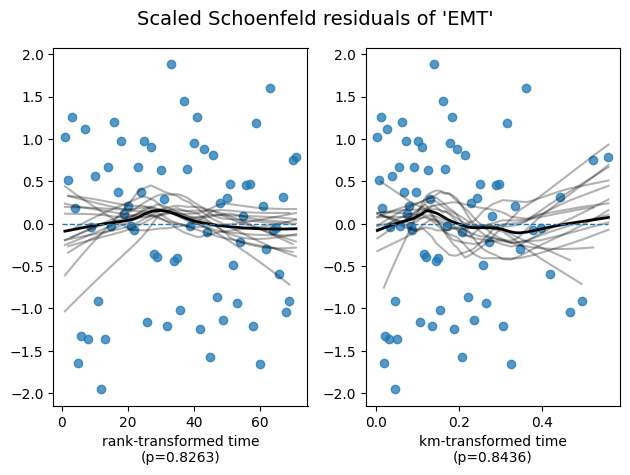

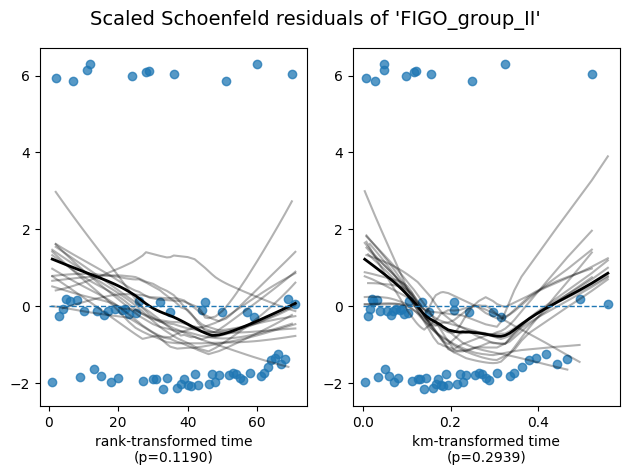

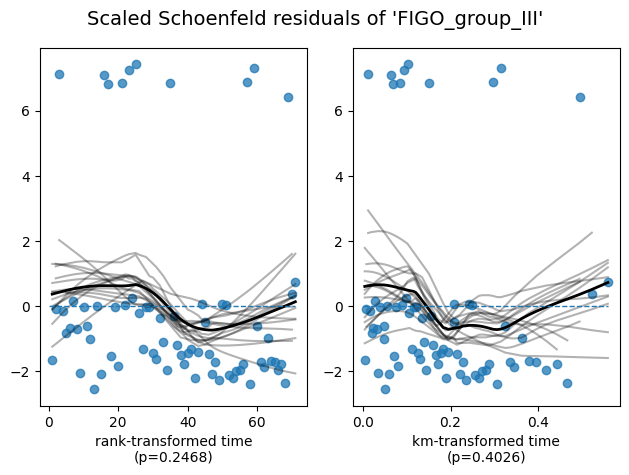

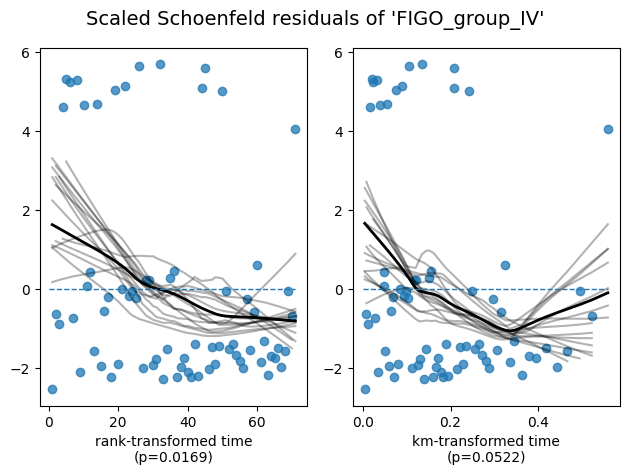

In [22]:
#check model assumptions
cph.check_assumptions(
    cox_model,
    p_value_threshold=0.05,
    show_plots=True
)

In [23]:
#Bootstrap validation
cox_boot = cox_model.copy()


In [24]:
c_apparent = cph.score(cox_boot, scoring_method="concordance_index")
print("Apparent C-index:", float(c_apparent))

Apparent C-index: 0.6842879470442218


In [25]:
cox_model[["FIGO_group_II", "FIGO_group_III", "FIGO_group_IV"]].sum()
cox_model.groupby("event")[["FIGO_group_II", "FIGO_group_III", "FIGO_group_IV"]].sum()

,FIGO_group_II,FIGO_group_III,FIGO_group_IV
event,,,
0,53,31,7
1,11,10,14


In [26]:
from lifelines import CoxPHFitter
from lifelines.exceptions import ConvergenceError
import numpy as np

cox_boot = cox_model.copy()

cph_full = CoxPHFitter(penalizer=0.01)
cph_full.fit(cox_boot, duration_col="time_days", event_col="event")
c_apparent = cph_full.score(cox_boot, scoring_method="concordance_index")

B = 1000
rng = np.random.default_rng(123)

optimisms = []
failed = 0
n = len(cox_boot)

for b in range(B):
    idx = rng.integers(0, n, size=n)
    boot = cox_boot.iloc[idx].copy()

    try:
        cph_b = CoxPHFitter(penalizer=0.01)
        cph_b.fit(boot, duration_col="time_days", event_col="event")

        c_train = cph_b.score(boot, scoring_method="concordance_index")
        c_test = cph_b.score(cox_boot, scoring_method="concordance_index")
        optimisms.append(float(c_train - c_test))

    except ConvergenceError:
        failed += 1

mean_optimism = np.mean(optimisms)
c_corrected = c_apparent - mean_optimism

print("Apparent C-index:", float(c_apparent))
print("Successful iterations:", len(optimisms))
print("Failed iterations:", failed)
print("Mean optimism:", float(mean_optimism))
print("Optimism-corrected C-index:", float(c_corrected))

/home/annettestomakhin/Magistritöö/.venv/lib/python3.12/site-packages/lifelines/utils/__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
/home/annettestomakhin/Magistritöö/.venv/lib/python3.12/site-packages/lifelines/utils/__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
/home/annettestomakhin/Magistritöö/.venv/lib/python3.12/site-packages/lifelines/utils/__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
/home/annettestomakhin/Magistritöö/.venv/lib/python3.12/site-packages/lifelines/utils/__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting

Apparent C-index: 0.6842879470442218
Successful iterations: 1000
Failed iterations: 0
Mean optimism: 0.021666271558987732
Optimism-corrected C-index: 0.6626216754852341


/home/annettestomakhin/Magistritöö/.venv/lib/python3.12/site-packages/lifelines/utils/__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
/home/annettestomakhin/Magistritöö/.venv/lib/python3.12/site-packages/lifelines/utils/__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
/home/annettestomakhin/Magistritöö/.venv/lib/python3.12/site-packages/lifelines/utils/__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
/home/annettestomakhin/Magistritöö/.venv/lib/python3.12/site-packages/lifelines/utils/__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting